# Transformación de datos: el primer paso hacia el modelo

En este cuaderno vamos a trabajar una etapa muy importante dentro del pipeline de **Machine Learning**: la preparación de los datos antes del entrenamiento de un modelo.

Muchas veces, los datos originales no están listos para ser usados directamente. Puede haber variables categóricas que deban convertirse en números, variables numéricas con escalas muy diferentes entre sí, valores extremos que distorsionen el análisis o atributos que convenga transformar para representar mejor el problema. Todo ese trabajo previo forma parte de una fase clave: la transformación de datos.

A lo largo de este cuaderno vamos a recorrer algunos de los procedimientos más habituales en esta etapa. Veremos una introducción al *feature engineering*, trabajaremos con ejemplos de fechas y márgenes, transformaremos variables categóricas con técnicas como **Label Encoding** y **One-Hot Encoding**, y analizaremos distintas formas de escalar variables numéricas, como la **normalización** y la **estandarización**. También exploraremos qué puede ocurrir cuando no escalamos los datos y cerraremos con una introducción a la detección y tratamiento de **outliers**.

## Objetivos del cuaderno

Al finalizar este recorrido, se espera que podamos:

- comprender por qué la transformación de datos es una etapa fundamental del pipeline;
- reconocer situaciones en las que conviene crear nuevas variables a partir de las existentes;
- aplicar transformaciones básicas sobre variables categóricas;
- diferenciar normalización y estandarización, entendiendo en qué casos puede resultar conveniente cada una;
- observar el efecto de trabajar con variables numéricas en escalas diferentes;
- identificar valores atípicos y analizar estrategias posibles para tratarlos.

La idea no será solamente ejecutar código, sino también interpretar qué estamos haciendo en cada paso y por qué ese paso puede mejorar el trabajo posterior con los datos y los modelos.

## Transformación de datos y Feature Engineering

En un proyecto de Machine Learning, los datos no siempre pueden usarse tal como fueron recolectados. Algunas variables necesitan cambiar de formato, otras deben convertirse en valores numéricos, y otras conviene ajustarlas o combinarlas para representar mejor el problema.

A este trabajo de crear, transformar, seleccionar o eliminar variables lo llamamos **Feature Engineering**. Cada variable, o **feature**, aporta información que el modelo puede usar para aprender.

Por ejemplo, a partir de una fecha podemos extraer el mes o el día de la semana; una variable categórica puede transformarse en números; y dos columnas numéricas pueden combinarse para crear una nueva variable más informativa.

Esta etapa es fundamental porque una buena representación de los datos puede facilitar el entrenamiento del modelo y mejorar sus resultados.

## Conjunto de datos elegido

Para este cuaderno vamos a trabajar con el dataset **Customer Personality Analysis**. Este conjunto de datos resulta adecuado porque combina variables categóricas, numéricas y temporales, lo que permite mostrar ejemplos pertinentes de transformación, codificación, escalado y detección de valores atípicos.

* [Dataset en Kaggle](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)

Vamos a cargarlo en Pandas:

In [ ]:
# ==========================================================
# CARGAMOS EL DATASET
# ==========================================================
import os
import pandas as pd

try:
    import kagglehub
except ImportError:
    !pip install -q kagglehub
    import kagglehub

try:
    df = pd.read_csv("marketing_campaign.csv", sep="\t")
    print("Dataset cargado desde el archivo local 'marketing_campaign.csv'")
except Exception:
    print("No se encontró 'marketing_campaign.csv' en el entorno local.")
    print("Descargando dataset desde Kaggle...")

    ruta_dataset = kagglehub.dataset_download("imakash3011/customer-personality-analysis")
    ruta_csv = os.path.join(ruta_dataset, "marketing_campaign.csv")

    df = pd.read_csv(ruta_csv, sep="\t")
    print("Dataset descargado y cargado correctamente desde Kaggle")

# Mostramos las primeras filas para verificar la carga
df.head()

No se encontró 'marketing_campaign.csv' en el entorno local.
Descargando dataset desde Kaggle...
Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Dataset descargado y cargado correctamente desde Kaggle


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Exploración inicial del conjunto de datos

Antes de aplicar transformaciones, conviene observar la estructura general del dataset. Esto nos permitirá identificar qué columnas pueden resultar útiles para crear nuevas variables, cuáles necesitan codificación y cuáles podrían requerir escalado o revisión de valores atípicos.

In [ ]:
# ==========================================================
# EXPLORAMOS LA ESTRUCTURA GENERAL DEL DATASET
# ==========================================================

print("Dimensiones del dataset:", df.shape)
print("\nColumnas disponibles:")
print(df.columns.tolist())

Dimensiones del dataset: (2240, 29)

Columnas disponibles:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [ ]:
# ==========================================================
# REVISAMOS TIPOS DE DATOS Y VALORES FALTANTES
# ==========================================================

#df.info()

print("\nCantidad de valores nulos por columna:")
print(df.isnull().sum())


Cantidad de valores nulos por columna:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


## Selección de columnas para los ejemplos

A partir de esta primera inspección, vamos a elegir algunas columnas representativas para mostrar distintas transformaciones. La idea no será trabajar con todo el dataset al mismo tiempo, sino enfocarnos en ejemplos claros y pertinentes para cada técnica.

## Columnas que usaremos en los ejemplos

Aunque el dataset incluye muchas variables, en este cuaderno vamos a trabajar con un grupo reducido de columnas útiles para mostrar distintas transformaciones.

* **Dt_Customer**, que indica la fecha de alta del cliente. Servirá para construir nuevas variables a partir del tiempo, por ejemplo el año de alta o la antigüedad del cliente.

* **Income**, el ingreso anual del cliente. Como es una variable numérica y además tiene algunos valores faltantes, será útil para mostrar tratamiento de nulos, escalado y detección de outliers.

* **Education** y **Marital_Status** (categóricas). Estas columnas describen características del cliente y nos permitirán ejemplificar técnicas de transformación como **Label Encoding** y **One-Hot Encoding**.

* **MntWines**, **MntMeatProducts** y **MntGoldProds**, que indican cuánto gastó cada cliente en distintas categorías de productos. Con ellas podremos crear nuevas variables, como un gasto total o comparaciones entre categorías.

* **Kidhome** y **Teenhome** también pueden resultar útiles para construir atributos derivados, ya que indican la cantidad de niños y adolescentes en el hogar.

La idea será usar estas columnas porque permiten mostrar, de forma clara y pertinente, varias de las transformaciones más comunes dentro del preprocesamiento de datos.

In [ ]:
# ==========================================================
# SELECCIONAMOS ALGUNAS COLUMNAS PARA LOS TRABAJAR
# ==========================================================

columnas_ejemplo = [
    "Dt_Customer",
    "Income",
    "Education",
    "Marital_Status",
    "Kidhome",
    "Teenhome",
    "MntWines",
    "MntMeatProducts",
    "MntGoldProds"
]

df[columnas_ejemplo].head()

,Dt_Customer,Income,Education,Marital_Status,Kidhome,Teenhome,MntWines,MntMeatProducts,MntGoldProds
0,04-09-2012,58138.0,Graduation,Single,0,0,635,546,88
1,08-03-2014,46344.0,Graduation,Single,1,1,11,6,6
2,21-08-2013,71613.0,Graduation,Together,0,0,426,127,42
3,10-02-2014,26646.0,Graduation,Together,1,0,11,20,5
4,19-01-2014,58293.0,PhD,Married,1,0,173,118,15


## Ejemplo de Feature Engineering con fechas y variables derivadas

Vamos a comenzar creando nuevas variables a partir de columnas existentes. Este tipo de transformación busca representar mejor la información original y puede aportar señales más útiles para el análisis o el modelado.

`Dt_Customer` contiene la fecha en la que cada cliente fue incorporado a la base. En lugar de dejar esa información tal como está, podemos transformarla para obtener variables más útiles para el análisis.

Por ejemplo, podemos extraer el año o el mes de alta, o calcular cuántos días pasaron desde que el cliente ingresó. Este tipo de transformación permite representar mejor la información temporal.

In [ ]:
# ==========================================================
# CONVERTIMOS LA COLUMNA DE FECHA
# ==========================================================

# Hacemos una copia para trabajar con más seguridad
df_transformado = df.copy()

# Convertimos la columna Dt_Customer a formato fecha
df_transformado["Dt_Customer"] = pd.to_datetime(
    df_transformado["Dt_Customer"],
    format="%d-%m-%Y"
    )

# Verificamos el cambio
df_transformado[["Dt_Customer"]].head()

,Dt_Customer
0,2012-09-04
1,2014-03-08
2,2013-08-21
3,2014-02-10
4,2014-01-19


### Crear columnas derivadas

A partir de una única columna de fecha, generamos tres nuevas variables: el año de alta, el mes de alta y la antigüedad del cliente.

Esto muestra una idea central del **Feature Engineering**: muchas veces una variable original contiene información que puede aprovecharse mejor si la descomponemos o la transformamos en nuevas características más específicas.

In [ ]:
# ==========================================================
# CREAMOS NUEVAS VARIABLES A PARTIR DE LA FECHA
# ==========================================================
from datetime import date

# Extraemos el año y el mes de alta del cliente
 # (se podría poner a mano)
df_transformado["Anio_Alta"] = df_transformado["Dt_Customer"].dt.year
df_transformado["Mes_Alta"] = df_transformado["Dt_Customer"].dt.month

# Calculamos la antigüedad del cliente en días (OJO con el tipo!!!)
#fecha_referencia = df_transformado["Dt_Customer"].max()
fecha_referencia = pd.to_datetime(date.today())
df_transformado["Antiguedad_Cliente_Dias"] = (fecha_referencia - df_transformado["Dt_Customer"]).dt.days

# Mostramos algunas columnas para revisar el resultado
df_transformado[["Dt_Customer", "Anio_Alta", "Mes_Alta", "Antiguedad_Cliente_Dias"]].head()

,Dt_Customer,Anio_Alta,Mes_Alta,Antiguedad_Cliente_Dias
0,2012-09-04,2012,9,4964
1,2014-03-08,2014,3,4414
2,2013-08-21,2013,8,4613
3,2014-02-10,2014,2,4440
4,2014-01-19,2014,1,4462


## Ejemplo con variables numéricas

Otra posibilidad es crear nuevas variables combinando columnas ya existentes. En este caso, vamos a construir una variable de gasto total a partir de tres categorías de productos.

Este tipo de transformación puede ser útil cuando nos interesa resumir varias medidas en un solo indicador más fácil de interpretar.

In [ ]:
# ==========================================================
# CREAMOS UNA VARIABLE DERIVADA DE GASTO TOTAL
# ==========================================================

df_transformado["Gasto_Total_Seleccionado"] = (
    df_transformado["MntWines"] +
    df_transformado["MntMeatProducts"] +
    df_transformado["MntGoldProds"]
)

df_transformado[["MntWines",
                 "MntMeatProducts",
                 "MntGoldProds",
                 "Gasto_Total_Seleccionado"]].head()

,MntWines,MntMeatProducts,MntGoldProds,Gasto_Total_Seleccionado
0,635,546,88,1269
1,11,6,6,23
2,426,127,42,595
3,11,20,5,36
4,173,118,15,306


En este ejemplo, la nueva variable `Gasto_Total_Seleccionado` resume el gasto del cliente en tres categorías de productos.

Aunque las columnas originales siguen siendo valiosas, esta nueva variable puede resultar útil cuando queremos trabajar con una medida más general del consumo.

----

## Transformación de variables categóricas

Muchas veces los conjuntos de datos incluyen variables categóricas, es decir, columnas cuyos valores representan clases o categorías, como nivel educativo o estado civil.

Como la mayoría de los modelos de Machine Learning trabajan con números, estas variables suelen necesitar alguna transformación previa. Dos de las técnicas más comunes son **Label Encoding** y **One-Hot Encoding**.

### Revisión de categorías

Antes de aplicar una transformación, conviene observar qué valores aparecen en cada variable categórica. Esto nos permite entender mejor la información disponible y verificar qué categorías serán codificadas.

In [ ]:
# ==========================================================
# OBSERVAMOS LAS CATEGORÍAS DISPONIBLES
# ==========================================================

print("Valores únicos en Education:")
print(df_transformado["Education"].unique())

print("\nValores únicos en Marital_Status:")
print(df_transformado["Marital_Status"].unique())

Valores únicos en Education:
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']

Valores únicos en Marital_Status:
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


### Label Encoding

El **Label Encoding** consiste en reemplazar cada categoría por un número entero.

Es una transformación simple y útil en algunos casos, aunque hay que aplicarla con cuidado: al convertir categorías en números, puede dar la impresión de que existe un orden entre ellas, incluso cuando ese orden no tiene sentido real.

En la siguiente celda vamos a transformar la columna `Education` mediante **Label Encoding**. Para eso, asignaremos un número entero distinto a cada categoría presente en la variable.



In [ ]:
# ==========================================================
# APLICAMOS LABEL ENCODING A EDUCATION
# ==========================================================
from sklearn.preprocessing import LabelEncoder

# Creamos el codificador
codificador_label = LabelEncoder()

# Generamos una nueva columna codificada
df_transformado["Education_Label"] = codificador_label.fit_transform(df_transformado["Education"])

# Mostramos la correspondencia entre categorías y números
mapeo_education = dict(zip(codificador_label.classes_, codificador_label.transform(codificador_label.classes_)))
print("Codificación aplicada en Education:")
print(mapeo_education)

df_transformado[["Education", "Education_Label"]].head(10)

Codificación aplicada en Education:
{'2n Cycle': np.int64(0), 'Basic': np.int64(1), 'Graduation': np.int64(2), 'Master': np.int64(3), 'PhD': np.int64(4)}


,Education,Education_Label
0,Graduation,2
1,Graduation,2
2,Graduation,2
3,Graduation,2
4,PhD,4
5,Master,3
6,Graduation,2
7,PhD,4
8,PhD,4
9,PhD,4


En este caso, cada nivel educativo fue reemplazado por un número entero. Es una forma rápida de transformar una variable categórica, pero no siempre es la más adecuada para usar directamente en un modelo, porque esos números podrían interpretarse como si hubiera una distancia u orden real entre categorías.

### One-Hot Encoding

Ahora vamos a aplicar **One-Hot Encoding** sobre la columna `Marital_Status`. Esta transformación generará una nueva columna binaria para cada categoría posible, indicando con `1` si esa categoría está presente y con `0` en caso contrario.

In [ ]:
# ==========================================================
# APLICAMOS ONE-HOT ENCODING A MARITAL_STATUS
# ==========================================================

# Creamos variables dummy a partir de Marital_Status
df_marital_dummies = pd.get_dummies(df_transformado["Marital_Status"], prefix="EstadoCivil")

# Mostramos las primeras filas
df_marital_dummies.head()

,EstadoCivil_Absurd,EstadoCivil_Alone,EstadoCivil_Divorced,EstadoCivil_Married,EstadoCivil_Single,EstadoCivil_Together,EstadoCivil_Widow,EstadoCivil_YOLO
0,False,False,False,False,True,False,False,False
1,False,False,False,False,True,False,False,False
2,False,False,False,False,False,True,False,False
3,False,False,False,False,False,True,False,False
4,False,False,False,True,False,False,False,False


### Comparación con la variable original

Para entender mejor el resultado, en la siguiente celda vamos a mostrar la columna original junto con las nuevas columnas generadas por el One-Hot Encoding.

In [ ]:
# ==========================================================
# COMPARAMOS LA COLUMNA ORIGINAL CON EL ONE-HOT ENCODING
# ==========================================================

pd.concat(
    [df_transformado[["Marital_Status"]].head(10),
    df_marital_dummies.head(10)],
    axis=1
)

,Marital_Status,EstadoCivil_Absurd,EstadoCivil_Alone,EstadoCivil_Divorced,EstadoCivil_Married,EstadoCivil_Single,EstadoCivil_Together,EstadoCivil_Widow,EstadoCivil_YOLO
0,Single,False,False,False,False,True,False,False,False
1,Single,False,False,False,False,True,False,False,False
2,Together,False,False,False,False,False,True,False,False
3,Together,False,False,False,False,False,True,False,False
4,Married,False,False,False,True,False,False,False,False
5,Together,False,False,False,False,False,True,False,False
6,Divorced,False,False,True,False,False,False,False,False
7,Married,False,False,False,True,False,False,False,False
8,Together,False,False,False,False,False,True,False,False
9,Together,False,False,False,False,False,True,False,False


A diferencia del Label Encoding, el One-Hot Encoding no reemplaza cada categoría por un único número. En cambio, crea una representación binaria que evita introducir un orden artificial entre las categorías.

Por eso, suele ser una alternativa más adecuada cuando trabajamos con variables categóricas sin jerarquía natural.

---
## Normalización y estandarización de variables numéricas

Cuando trabajamos con variables numéricas, no siempre todas están expresadas en escalas comparables. Algunas pueden tomar valores pequeños, mientras que otras manejan magnitudes mucho mayores.

En ciertos modelos, estas diferencias de escala pueden influir en el resultado. Por eso, en muchos casos conviene aplicar técnicas de escalado, como la **normalización** o la **estandarización**.

### Variable elegida para el ejemplo

En las próximas celdas vamos a trabajar con la columna `Income`, que representa el ingreso anual del cliente. Como es una variable numérica y además presenta algunos valores faltantes, resulta adecuada para ilustrar distintas transformaciones.

In [ ]:
# ==========================================================
# PREPARAMOS LA VARIABLE NUMÉRICA PARA EL ESCALADO
# ==========================================================

# Tomamos la columna Income y eliminamos los valores nulos
income = df_transformado[["Income"]].dropna()

print("Cantidad de filas originales:", len(df_transformado))
print("Cantidad de filas sin nulos en Income:", len(income))

income.head()

Cantidad de filas originales: 2240
Cantidad de filas sin nulos en Income: 2216


,Income
0,58138.0
1,46344.0
2,71613.0
3,26646.0
4,58293.0


### Normalización (Min-Max Scaling)

En la siguiente celda vamos a aplicar **normalización**, una técnica que transforma los valores para que queden dentro de un rango acotado, generalmente entre 0 y 1.

Esto resulta útil cuando queremos comparar variables en una misma escala o cuando el modelo es sensible a las diferencias de magnitud.

In [ ]:
# ==========================================================
# APLICAMOS NORMALIZACIÓN A INCOME
# ==========================================================
from sklearn.preprocessing import MinMaxScaler

# Creamos el escalador
escalador_minmax = MinMaxScaler()

# Generamos una nueva columna normalizada
income["Income_Normalizado"] = escalador_minmax.fit_transform(income[["Income"]])

income.head(10)

,Income,Income_Normalizado
0,58138.0,0.084832
1,46344.0,0.067095
2,71613.0,0.105097
3,26646.0,0.037471
4,58293.0,0.085065
5,62513.0,0.091412
6,55635.0,0.081068
7,33454.0,0.047710
8,30351.0,0.043043
9,5648.0,0.005892


Después de la normalización, los valores de `Income` quedan reescalados entre 0 y 1. El menor valor de la columna pasa a ubicarse en 0, y el mayor en 1, mientras que los demás quedan distribuidos proporcionalmente dentro de ese intervalo.

### Estandarización (Z-score Scaling)

Ahora vamos a aplicar **estandarización**. A diferencia de la normalización, esta técnica no lleva los datos a un rango fijo, sino que los transforma para que tengan media 0 y desvío estándar 1.

Esto permite expresar cada valor en función de qué tan alejado está del promedio.

In [ ]:
# ==========================================================
# APLICAMOS ESTANDARIZACIÓN A INCOME
# ==========================================================
from sklearn.preprocessing import StandardScaler

# Creamos el escalador
escalador_standard = StandardScaler()

# Generamos una nueva columna estandarizada
income["Income_Estandarizado"] = escalador_standard.fit_transform(income[["Income"]])

income.head(10)

,Income,Income_Normalizado,Income_Estandarizado
0,58138.0,0.084832,0.234063
1,46344.0,0.067095,-0.234559
2,71613.0,0.105097,0.769478
3,26646.0,0.037471,-1.017239
4,58293.0,0.085065,0.240221
5,62513.0,0.091412,0.407899
6,55635.0,0.081068,0.134609
7,33454.0,0.047710,-0.746730
8,30351.0,0.043043,-0.870025
9,5648.0,0.005892,-1.851572


Después de la estandarización, los valores de `Income` ya no se interpretan en su escala original, sino en relación con el promedio de la variable. Un valor positivo indica que está por encima de la media, y uno negativo que está por debajo.

### Comparación de resultados

En la siguiente celda vamos a comparar la variable original con sus versiones normalizada y estandarizada, para observar cómo cambia su escala.

In [ ]:
# ==========================================================
# COMPARAMOS LA VARIABLE ORIGINAL Y SUS VERSIONES ESCALADAS
# ==========================================================

income[["Income", "Income_Normalizado", "Income_Estandarizado"]].head(10)

,Income,Income_Normalizado,Income_Estandarizado
0,58138.0,0.084832,0.234063
1,46344.0,0.067095,-0.234559
2,71613.0,0.105097,0.769478
3,26646.0,0.037471,-1.017239
4,58293.0,0.085065,0.240221
5,62513.0,0.091412,0.407899
6,55635.0,0.081068,0.134609
7,33454.0,0.047710,-0.746730
8,30351.0,0.043043,-0.870025
9,5648.0,0.005892,-1.851572


## ¿Qué pasa si no escalamos los datos?

No todos los modelos se ven afectados de la misma manera por la escala de las variables. Sin embargo, en algunos casos, trabajar con magnitudes muy diferentes puede hacer que una variable tenga más peso que otra simplemente por sus valores numéricos, y no por su verdadera importancia.

Para ilustrarlo, vamos a comparar dos variables con escalas distintas.

### Selección de variables para el ejemplo

En la siguiente celda vamos a tomar dos variables numéricas: `Income`, que maneja valores muy altos, y `MntWines`, que representa gasto en vino y tiene una escala mucho menor. Esto nos permitirá observar con claridad la diferencia de magnitudes.

In [ ]:
# ==========================================================
# SELECCIONAMOS DOS VARIABLES CON ESCALAS DIFERENTES
# ==========================================================

df_escalado = df_transformado[["Income", "MntWines"]].dropna()

df_escalado.head()

,Income,MntWines
0,58138.0,635
1,46344.0,11
2,71613.0,426
3,26646.0,11
4,58293.0,173


### Visualización sin escalado

En la siguiente celda vamos a observar ambas variables en su escala original. Esto nos ayudará a ver cómo una de ellas domina visualmente por manejar valores mucho mayores.

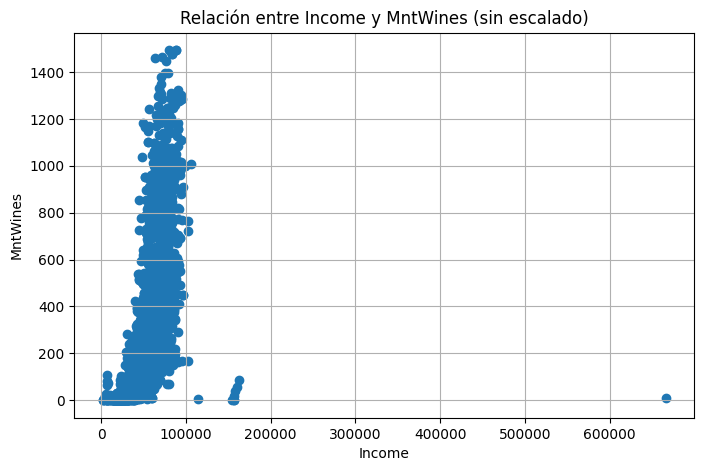

In [ ]:
# ==========================================================
# GRAFICAMOS LAS VARIABLES EN SU ESCALA ORIGINAL
# ==========================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df_escalado["Income"], df_escalado["MntWines"])
plt.xlabel("Income")
plt.ylabel("MntWines")
plt.title("Relación entre Income y MntWines (sin escalado)")
plt.grid(True)
plt.show()

En este gráfico, ambas variables conservan su escala original. Como `Income` toma valores mucho más grandes que `MntWines`, la diferencia de magnitud es muy marcada.

En modelos sensibles a la distancia, esta disparidad puede hacer que la variable con valores más altos influya más de lo deseado.

### Visualización con escalado

Ahora vamos a escalar ambas variables para llevarlas a una escala comparable. De esta manera podremos observarlas en condiciones más equilibradas.

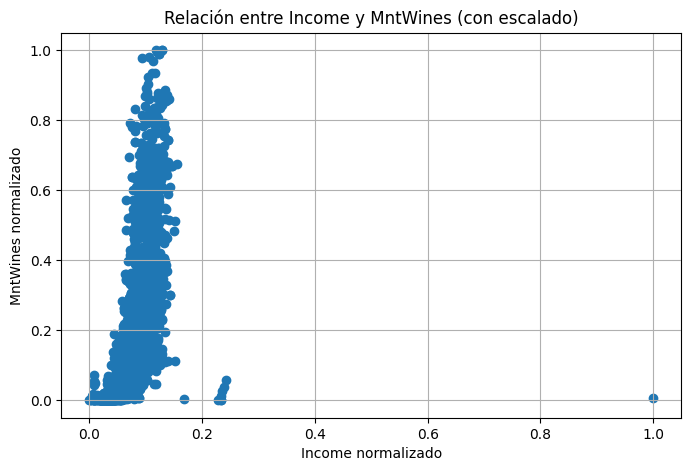

In [ ]:
# ==========================================================
# NORMALIZAMOS AMBAS VARIABLES Y VOLVEMOS A GRAFICAR
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

escalador = MinMaxScaler()
variables_escaladas = escalador.fit_transform(df_escalado[["Income", "MntWines"]])

df_escalado_norm = pd.DataFrame(
    variables_escaladas,
    columns=["Income_Normalizado", "MntWines_Normalizado"]
)

plt.figure(figsize=(8, 5))
plt.scatter(df_escalado_norm["Income_Normalizado"], df_escalado_norm["MntWines_Normalizado"])
plt.xlabel("Income normalizado")
plt.ylabel("MntWines normalizado")
plt.title("Relación entre Income y MntWines (con escalado)")
plt.grid(True)
plt.show()

Después del escalado, ambas variables quedan representadas dentro de un rango comparable. Esto no cambia la relación entre los datos, pero sí evita que una variable predomine sobre otra solo por su escala numérica.

Por eso, el escalado puede ser especialmente importante en modelos que trabajan con distancias o comparaciones directas entre variables.

### Interpretación del resultado

Aunque las escalas cambiaron, la nube de puntos mantiene una forma muy parecida. Esto es esperable, porque la normalización no altera la relación general entre los datos: solo cambia el rango de los valores.

Dicho de otro modo, el escalado no “reordena” los puntos ni modifica la estructura del conjunto, sino que expresa las variables en una escala comparable.

En este ejemplo, además, la variable `Income` presenta un valor extremo muy alto. Eso hace que, incluso después de normalizar, gran parte de los datos quede concentrada en una zona pequeña del gráfico. Este efecto anticipa un tema importante que veremos a continuación: la presencia de **outliers**.

-----
## Detección y tratamiento de outliers

En el ejemplo anterior vimos que la variable `Income` incluye valores muy altos en comparación con la mayoría de los casos. Ese tipo de observaciones se conoce como **outliers** o valores atípicos.

Los outliers pueden influir en el análisis, en las visualizaciones y también en algunos modelos. Por eso, conviene detectarlos y evaluar cómo tratarlos según el contexto.

### Observación visual de posibles valores atípicos

En la siguiente celda vamos a usar un diagrama de caja (*boxplot*) para observar la distribución de `Income` e identificar visualmente posibles outliers.

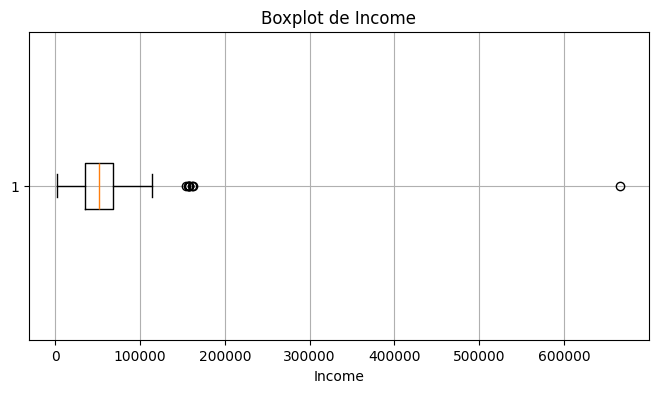

In [ ]:
# ==========================================================
# VISUALIZAMOS POSIBLES OUTLIERS EN INCOME
# ==========================================================

plt.figure(figsize=(8, 4))
plt.boxplot(df_transformado["Income"].dropna(), vert=False)
plt.title("Boxplot de Income")
plt.xlabel("Income")
plt.grid(True)
plt.show()

El boxplot permite detectar valores que se alejan claramente del comportamiento general de la variable. En este caso, se observan algunos ingresos muy altos que podrían considerarse valores atípicos.

### Detección mediante el criterio del rango intercuartílico

Además de la observación visual, podemos detectar outliers usando una regla sencilla basada en el **rango intercuartílico** (IQR). Esta técnica considera atípicos a los valores que quedan muy por debajo o muy por encima del rango central de los datos.

In [ ]:
# ==========================================================
# DETECTAMOS OUTLIERS CON EL MÉTODO IQR
# ==========================================================

income_limpio = df_transformado["Income"].dropna()

Q1 = income_limpio.quantile(0.25)
Q3 = income_limpio.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_income = income_limpio[
    (income_limpio < limite_inferior) | (income_limpio > limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Cantidad de outliers detectados:", len(outliers_income))

Q1: 35303.0
Q3: 68522.0
IQR: 33219.0
Límite inferior: -14525.5
Límite superior: 118350.5
Cantidad de outliers detectados: 8


### Revisión de algunos valores detectados

En la siguiente celda vamos a mostrar algunos de los ingresos identificados como atípicos para ver concretamente qué valores fueron marcados por este criterio.

In [ ]:
# ==========================================================
# MOSTRAMOS ALGUNOS OUTLIERS DETECTADOS
# ==========================================================

outliers_income.sort_values(ascending=False).head(10)

,Income
2233,666666.0
617,162397.0
687,160803.0
1300,157733.0
164,157243.0
1653,157146.0
2132,156924.0
655,153924.0


### ¿Qué podemos hacer con los outliers?

Detectar un outlier no significa que debamos eliminarlo automáticamente. A veces se trata de un error de carga, pero otras veces representa un caso real aunque poco frecuente.

Una estrategia posible es crear una versión filtrada del conjunto de datos, excluyendo esos valores extremos, para comparar cómo cambia la distribución.

In [ ]:
# ==========================================================
# CREAMOS UNA VERSIÓN FILTRADA SIN OUTLIERS EN INCOME
# ==========================================================

df_sin_outliers = df_transformado[
    (df_transformado["Income"].notna()) &
    (df_transformado["Income"] >= limite_inferior) &
    (df_transformado["Income"] <= limite_superior)
]

print("Filas originales con Income no nulo:", df_transformado["Income"].notna().sum())
print("Filas luego de filtrar outliers:", len(df_sin_outliers))

Filas originales con Income no nulo: 2216
Filas luego de filtrar outliers: 2208


### Comparación visual antes y después del filtrado

En la siguiente celda vamos a comparar la distribución de `Income` antes y después de excluir los valores atípicos detectados.

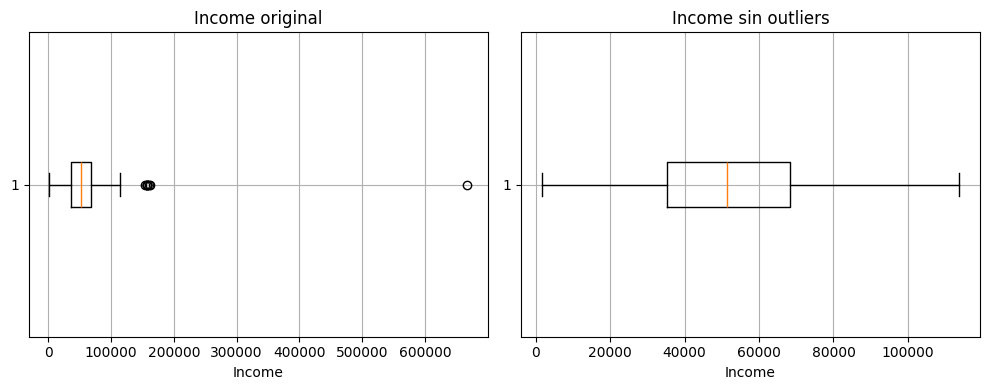

In [ ]:
# ==========================================================
# COMPARAMOS LA DISTRIBUCIÓN ANTES Y DESPUÉS DEL FILTRADO
# ==========================================================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df_transformado["Income"].dropna(), vert=False)
plt.title("Income original")
plt.xlabel("Income")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.boxplot(df_sin_outliers["Income"], vert=False)
plt.title("Income sin outliers")
plt.xlabel("Income")
plt.grid(True)

plt.tight_layout()
plt.show()

### Comentario final

Al excluir los valores atípicos, la distribución central de `Income` se observa con mayor claridad. Sin embargo, decidir si conviene eliminarlos, transformarlos o conservarlos depende siempre del problema que estemos analizando.

Por eso, el tratamiento de outliers no debe hacerse de forma automática, sino con criterio y teniendo en cuenta el contexto de los datos.

## Cierre

En este cuaderno recorrimos varias transformaciones habituales dentro de la preparación de datos para Machine Learning. Vimos cómo crear nuevas variables, cómo transformar columnas categóricas en formatos numéricos, cómo escalar variables con distintas magnitudes y cómo detectar valores atípicos.

Más allá de cada técnica puntual, la idea central es que los datos no suelen estar listos para usarse directamente. Prepararlos, comprenderlos y transformarlos adecuadamente es una parte fundamental del pipeline, y muchas veces tiene un impacto tan importante como la elección del modelo.

En la práctica, un buen trabajo de preprocesamiento no solo facilita el entrenamiento, sino que también ayuda a construir modelos más claros, más robustos y mejor adaptados al problema.